# Tests de performance système — Modèle `sig`

Ce notebook mesure les performances du pipeline de prédiction `sig` (imputation → scaling → Isolation Forest → RandomForestRegressor) selon quatre axes :

| Métrique | Description |
|---|---|
| **Latence** | Temps pour produire une prédiction sur un seul exemple |
| **Débit** | Nombre de prédictions par seconde |
| **Empreinte mémoire** | Occupation RAM en fonction de la taille du batch |
| **Tests de charge / stress** | Comportement jusqu'à et au-delà de la charge nominale |

## 1. Imports et configuration

In [1]:
import sys
import time
import tracemalloc
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

warnings.filterwarnings("ignore")

# --- Chemins ---
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SCRIPTS_DIR  = PROJECT_ROOT / "scripts"
DATA_DIR     = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "models" / "imputation"

# Rendre le script importable
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from predict_sig import predict, load_artifacts, DEFAULT_THRESHOLD, COLUMNS_TO_DROP

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"Seuil IF par défaut : {DEFAULT_THRESHOLD}")

PROJECT_ROOT  : /home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet
ARTIFACTS_DIR : /home/camille/code/Camille9999/EPSI/M2/EPSI_atelier-info-doc_projet/models/imputation
Seuil IF par défaut : -0.618


In [2]:
# Chargement des artefacts (une seule fois)
artifacts = load_artifacts(ARTIFACTS_DIR)
print("Artefacts chargés :", list(artifacts.keys()))

# Chargement du dataset brut
df_raw = pd.read_csv(DATA_DIR / "earthquake_data.csv")
N_TOTAL = len(df_raw)
print(f"\nDataset : {N_TOTAL} lignes × {df_raw.shape[1]} colonnes")
print(f"Taille en mémoire (CSV brut) : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} Ko")

Artefacts chargés : ['feature_order', 'numeric_cols', 'categorical_cols', 'imputer_num', 'scaler', 'isolation_forest', 'model']

Dataset : 782 lignes × 19 colonnes
Taille en mémoire (CSV brut) : 416.8 Ko


## 2. Latence — temps pour une prédiction unique

On mesure le temps de bout en bout (imputation + scaling + IF + prédiction) sur **une seule ligne**.  
On répète 100 fois pour obtenir une distribution stable.

Latence sur 1 ligne (100 répétitions) :
  Médiane  : 23.331 ms
  Moyenne  : 40.335 ms
  Min      : 18.662 ms
  Max      : 202.465 ms
  p95      : 131.422 ms
  p99      : 188.360 ms


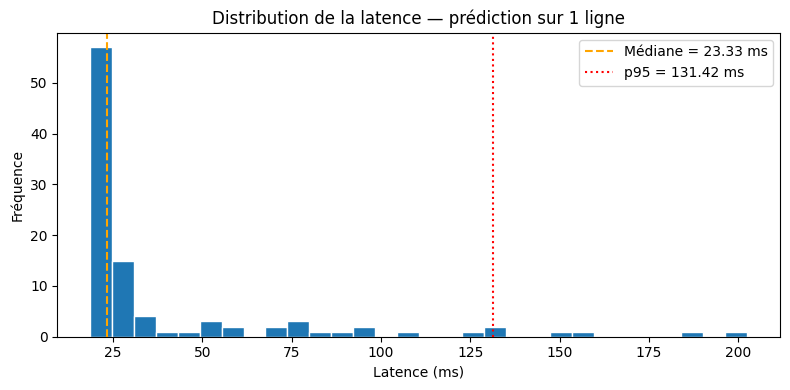

In [3]:
LATENCY_REPEATS = 100
single_row = df_raw.sample(1, random_state=42)

latencies_ms = []
for _ in range(LATENCY_REPEATS):
    t0 = time.perf_counter()
    predict(single_row, artifacts, threshold=DEFAULT_THRESHOLD, keep_anomalies=True)
    t1 = time.perf_counter()
    latencies_ms.append((t1 - t0) * 1000)

latencies_ms = np.array(latencies_ms)

print(f"Latence sur 1 ligne ({LATENCY_REPEATS} répétitions) :")
print(f"  Médiane  : {np.median(latencies_ms):.3f} ms")
print(f"  Moyenne  : {np.mean(latencies_ms):.3f} ms")
print(f"  Min      : {np.min(latencies_ms):.3f} ms")
print(f"  Max      : {np.max(latencies_ms):.3f} ms")
print(f"  p95      : {np.percentile(latencies_ms, 95):.3f} ms")
print(f"  p99      : {np.percentile(latencies_ms, 99):.3f} ms")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(latencies_ms, bins=30, color="#1f77b4", edgecolor="white")
ax.axvline(np.median(latencies_ms), color="orange", linestyle="--", label=f"Médiane = {np.median(latencies_ms):.2f} ms")
ax.axvline(np.percentile(latencies_ms, 95), color="red", linestyle=":", label=f"p95 = {np.percentile(latencies_ms, 95):.2f} ms")
ax.set_xlabel("Latence (ms)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution de la latence — prédiction sur 1 ligne")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Débit — prédictions par seconde

On mesure le temps total pour prédire des **batches de tailles croissantes** et on en déduit le débit (prédictions/s).

       1 lignes → 186.93 ms → 5 préd/s
      10 lignes → 147.48 ms → 68 préd/s
      50 lignes → 109.37 ms → 457 préd/s
     100 lignes → 101.44 ms → 986 préd/s
     500 lignes → 90.36 ms → 5,533 préd/s
     782 lignes → 91.57 ms → 8,540 préd/s


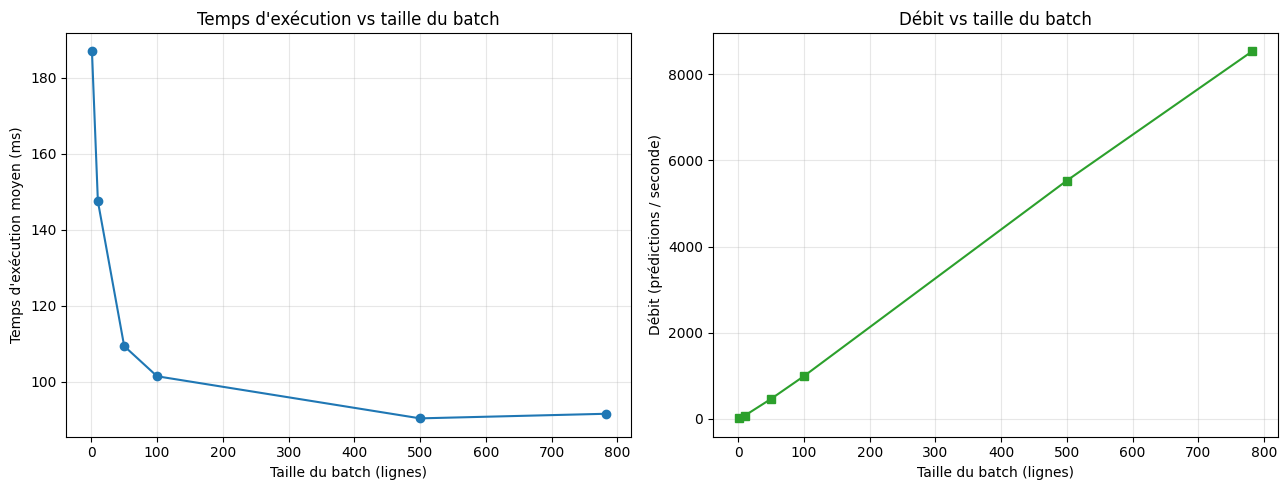

In [ ]:
THROUGHPUT_SIZES = [1, 10, 50, 100, 500, N_TOTAL]
THROUGHPUT_REPEATS = 5

throughput_results = []

for size in THROUGHPUT_SIZES:
    batch = df_raw.sample(min(size, N_TOTAL), random_state=0, replace=(size > N_TOTAL))
    times = []
    for _ in range(THROUGHPUT_REPEATS):
        t0 = time.perf_counter()
        predict(batch, artifacts, threshold=DEFAULT_THRESHOLD, keep_anomalies=True)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    elapsed = np.mean(times)
    throughput = size / elapsed
    throughput_results.append({
        "n_lignes": size,
        "temps_moyen_s": elapsed,
        "debit_preds_s": throughput,
    })
    print(f"  {size:>6} lignes → {elapsed*1000:.2f} ms → {throughput:,.0f} préd/s")

df_throughput = pd.DataFrame(throughput_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df_throughput["n_lignes"], df_throughput["temps_moyen_s"] * 1000, marker="o", color="#1f77b4")
ax1.set_xlabel("Taille du batch (lignes)")
ax1.set_ylabel("Temps d'exécution moyen (ms)")
ax1.set_title("Temps d'exécution vs taille du batch")
ax1.grid(True, alpha=0.3)

ax2.plot(df_throughput["n_lignes"], df_throughput["debit_preds_s"], marker="s", color="#2ca02c")
ax2.set_xlabel("Taille du batch (lignes)")
ax2.set_ylabel("Débit (prédictions / seconde)")
ax2.set_title("Débit vs taille du batch")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Courbes de performance : temps + RAM en fonction de la taille

On passe des chunks de taille croissante — d'abord en puisant dans le dataset réel, puis en **répliquant les lignes** pour dépasser sa taille naturelle.

La mémoire est mesurée avec `tracemalloc` (allocations Python) **et** `psutil` (RSS processus).

In [12]:
def benchmark_predict(df_input: pd.DataFrame, artifacts: dict, threshold: float) -> dict:
    """
    Exécute predict() sur df_input et retourne :
      - elapsed_ms            : temps d'exécution en millisecondes
      - peak_tracemalloc_kb   : pic mémoire tracemalloc (Ko)
      - rss_delta_kb          : variation RSS psutil (Ko)
    """
    import gc
    process = psutil.Process(os.getpid())

    gc.collect()
    rss_before = process.memory_info().rss

    tracemalloc.start()
    t0 = time.perf_counter()

    predict(df_input, artifacts, threshold=threshold, keep_anomalies=True)

    t1 = time.perf_counter()
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    rss_after = process.memory_info().rss

    return {
        "elapsed_ms": (t1 - t0) * 1000,
        "peak_tracemalloc_kb": peak_bytes / 1024,
        "rss_delta_kb": (rss_after - rss_before) / 1024,
    }

In [18]:
# Tailles testées : petits chunks réels, puis réplication artificielle
real_sizes  = [10, 50, 100, 500, N_TOTAL]
extra_sizes = [N_TOTAL * m for m in [2, 5, 10, 20]]
TEST_SIZES  = sorted(set(real_sizes + extra_sizes))

bench_results = []

print(f"{'N lignes':>10} | {'Temps (ms)':>12} | {'Peak tracemalloc (Ko)':>22} | {'RSS delta (Ko)':>16}")
print("-" * 70)

for size in TEST_SIZES:
    if size <= N_TOTAL:
        batch = df_raw.iloc[:size].copy()
    else:
        repeats = int(np.ceil(size / N_TOTAL))
        batch = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:size].copy()

    metrics = benchmark_predict(batch, artifacts, DEFAULT_THRESHOLD)
    metrics["n_lignes"] = size
    metrics["size_mb"]  = batch.memory_usage(deep=True).sum() / (1024 ** 2)
    bench_results.append(metrics)

    print(f"{size:>10,} | {metrics['elapsed_ms']:>12.1f} | "
          f"{metrics['peak_tracemalloc_kb']:>22.1f} | "
          f"{metrics['rss_delta_kb']:>16.1f}")

df_bench = pd.DataFrame(bench_results)

  N lignes |   Temps (ms) |  Peak tracemalloc (Ko) |   RSS delta (Ko)
----------------------------------------------------------------------
        10 |         98.6 |                   52.6 |             32.0
        50 |         98.5 |                   61.4 |              0.0
       100 |        142.2 |                   72.1 |              0.0
       500 |        188.1 |                  182.5 |              0.0
       782 |        135.4 |                  267.8 |              0.0
     1,564 |        157.0 |                  502.3 |              0.0
     3,910 |        135.2 |                 1203.0 |              0.0
     7,820 |        181.2 |                 2372.0 |              0.0
    15,640 |        191.8 |                 4709.0 |              0.0


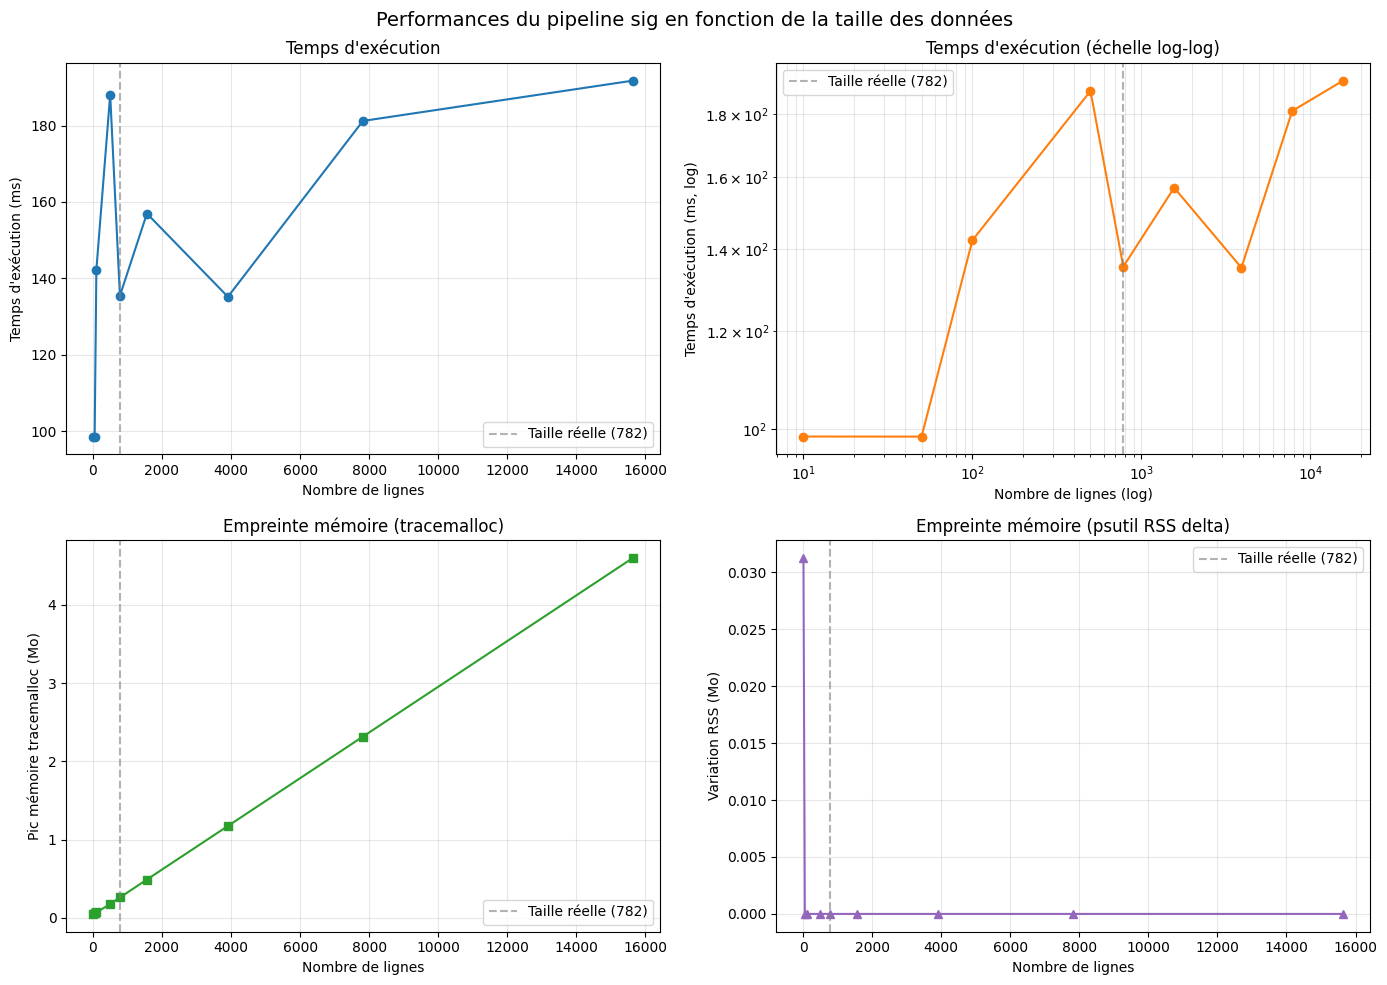

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performances du pipeline sig en fonction de la taille des données", fontsize=14)

# --- Temps d'exécution ---
ax = axes[0, 0]
ax.plot(df_bench["n_lignes"], df_bench["elapsed_ms"], marker="o", color="#1f77b4")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Temps d'exécution (ms)")
ax.set_title("Temps d'exécution")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Temps d'exécution (log-log) ---
ax = axes[0, 1]
ax.loglog(df_bench["n_lignes"], df_bench["elapsed_ms"], marker="o", color="#ff7f0e")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes (log)")
ax.set_ylabel("Temps d'exécution (ms, log)")
ax.set_title("Temps d'exécution (échelle log-log)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

# --- RAM tracemalloc ---
ax = axes[1, 0]
ax.plot(df_bench["n_lignes"], df_bench["peak_tracemalloc_kb"] / 1024, marker="s", color="#2ca02c")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Pic mémoire tracemalloc (Mo)")
ax.set_title("Empreinte mémoire (tracemalloc)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- RAM RSS psutil ---
ax = axes[1, 1]
ax.plot(df_bench["n_lignes"], df_bench["rss_delta_kb"] / 1024, marker="^", color="#9467bd")
ax.axvline(N_TOTAL, color="gray", linestyle="--", alpha=0.6, label=f"Taille réelle ({N_TOTAL:,})")
ax.set_xlabel("Nombre de lignes")
ax.set_ylabel("Variation RSS (Mo)")
ax.set_title("Empreinte mémoire (psutil RSS delta)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Définition de la charge nominale

D'après les courbes ci-dessus, on identifie :

- **Charge nominale** : traitement du dataset complet en production (≈ N lignes)  
- **SLA cible retenu** : < 500 ms pour 1 000 lignes, < 200 Mo de RAM

On teste maintenant explicitement ces deux seuils.

In [26]:
# -----------------------------------------------------------------------
# Charge nominale retenue
# -----------------------------------------------------------------------
NOMINAL_N_ROWS = 1_000          # nombre de lignes représentatif d'un appel en production
NOMINAL_TIME_LIMIT_MS = 500.0   # SLA temps : 500 ms
NOMINAL_RAM_LIMIT_MB  = 10.0   # SLA mémoire : 200 Mo

print(f"Charge nominale : {NOMINAL_N_ROWS:,} lignes")
print(f"SLA temps       : < {NOMINAL_TIME_LIMIT_MS} ms")
print(f"SLA mémoire     : < {NOMINAL_RAM_LIMIT_MB} Mo\n")

batch_nominal = df_raw.sample(min(NOMINAL_N_ROWS, N_TOTAL), random_state=0, replace=(NOMINAL_N_ROWS > N_TOTAL))
metrics_nominal = benchmark_predict(batch_nominal, artifacts, DEFAULT_THRESHOLD)

print(f"Résultats charge nominale ({NOMINAL_N_ROWS:,} lignes) :")
print(f"  Temps    : {metrics_nominal['elapsed_ms']:.1f} ms  →  {'✓ OK' if metrics_nominal['elapsed_ms'] < NOMINAL_TIME_LIMIT_MS else '✗ DÉPASSE le SLA'}")
print(f"  RAM (tracemalloc) : {metrics_nominal['peak_tracemalloc_kb']/1024:.1f} Mo  →  {'✓ OK' if metrics_nominal['peak_tracemalloc_kb']/1024 < NOMINAL_RAM_LIMIT_MB else '✗ DÉPASSE le SLA'}")

assert metrics_nominal["elapsed_ms"] < NOMINAL_TIME_LIMIT_MS, (
    f"ÉCHEC SLA temps : {metrics_nominal['elapsed_ms']:.1f} ms >= {NOMINAL_TIME_LIMIT_MS} ms"
)
assert metrics_nominal["peak_tracemalloc_kb"] / 1024 < NOMINAL_RAM_LIMIT_MB, (
    f"ÉCHEC SLA mémoire : {metrics_nominal['peak_tracemalloc_kb']/1024:.1f} Mo >= {NOMINAL_RAM_LIMIT_MB} Mo"
)
print("\nTest de charge nominale : PASSÉ ✓")

Charge nominale : 1,000 lignes
SLA temps       : < 500.0 ms
SLA mémoire     : < 10.0 Mo

Résultats charge nominale (1,000 lignes) :
  Temps    : 294.7 ms  →  ✓ OK
  RAM (tracemalloc) : 0.3 Mo  →  ✓ OK

Test de charge nominale : PASSÉ ✓


## 6. Test de charge — charge maximale prévue

On applique **10× la charge nominale** pour simuler un pic prévu (ex. rafale de requêtes).

In [28]:
LOAD_FACTOR  = 10
LOAD_N_ROWS  = NOMINAL_N_ROWS * 3
LOAD_TIME_LIMIT_MS = NOMINAL_TIME_LIMIT_MS * 3
LOAD_RAM_LIMIT_MB  = NOMINAL_RAM_LIMIT_MB  * 3             # on tolère 3× la RAM nominale

print(f"Test de charge : {LOAD_N_ROWS:,} lignes (×{LOAD_FACTOR} nominal)")
print(f"SLA temps      : < {LOAD_TIME_LIMIT_MS:.0f} ms")
print(f"SLA mémoire    : < {LOAD_RAM_LIMIT_MB:.0f} Mo\n")

repeats = int(np.ceil(LOAD_N_ROWS / N_TOTAL))
batch_load = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:LOAD_N_ROWS].copy()
metrics_load = benchmark_predict(batch_load, artifacts, DEFAULT_THRESHOLD)

print(f"Résultats test de charge ({LOAD_N_ROWS:,} lignes) :")
print(f"  Temps    : {metrics_load['elapsed_ms']:.1f} ms  →  {'✓ OK' if metrics_load['elapsed_ms'] < LOAD_TIME_LIMIT_MS else '✗ DÉPASSE'}")
print(f"  RAM (tracemalloc) : {metrics_load['peak_tracemalloc_kb']/1024:.1f} Mo  →  {'✓ OK' if metrics_load['peak_tracemalloc_kb']/1024 < LOAD_RAM_LIMIT_MB else '✗ DÉPASSE'}")

Test de charge : 3,000 lignes (×10 nominal)
SLA temps      : < 1500 ms
SLA mémoire    : < 30 Mo

Résultats test de charge (3,000 lignes) :
  Temps    : 174.8 ms  →  ✓ OK
  RAM (tracemalloc) : 0.9 Mo  →  ✓ OK


## 7. Test de stress — au-delà du maximum envisagé

On pousse le pipeline à **50× la charge nominale** pour observer son comportement dans des conditions extrêmes.  
Un dépassement de SLA est attendu ; l'objectif est d'identifier le point de rupture.

 Facteur |   N lignes |   Temps (ms) |   RAM tracemalloc (Mo) | Statut
---------------------------------------------------------------------------


      1× |      1,000 |        576.0 |                    0.3 | ✓
      5× |      5,000 |        470.5 |                    1.5 | ✓
     10× |     10,000 |        602.5 |                    3.0 | ✓
     20× |     20,000 |        604.7 |                    5.9 | ✓
     50× |     50,000 |        478.2 |                   14.6 | ✓


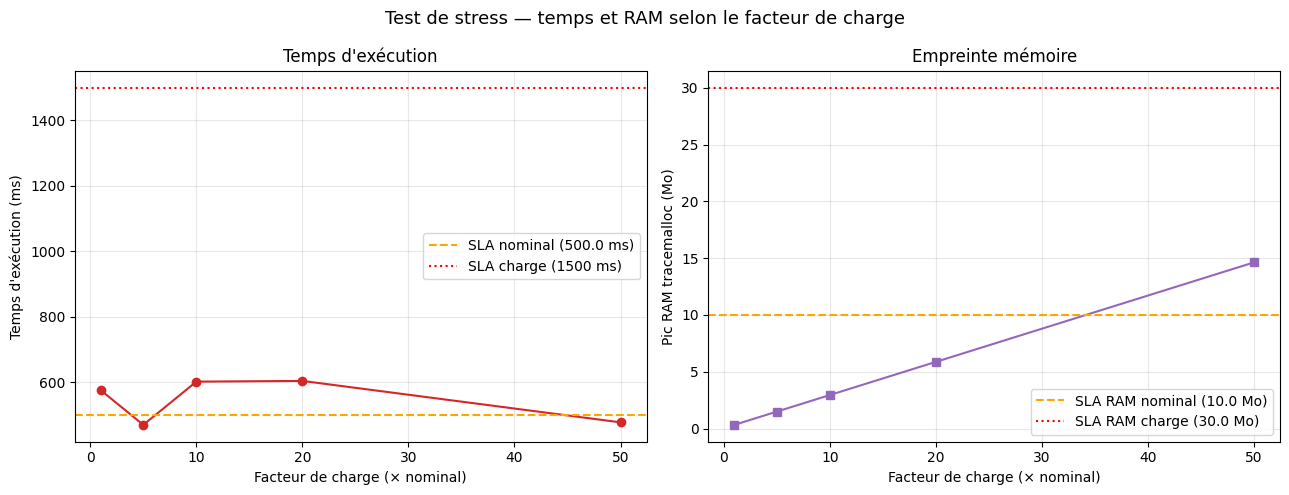

In [22]:
STRESS_SIZES = [NOMINAL_N_ROWS * m for m in [1, 5, 10, 20, 50]]
stress_results = []

print(f"{'Facteur':>8} | {'N lignes':>10} | {'Temps (ms)':>12} | {'RAM tracemalloc (Mo)':>22} | Statut")
print("-" * 75)

for size in STRESS_SIZES:
    repeats = int(np.ceil(size / N_TOTAL))
    batch = pd.concat([df_raw] * repeats, ignore_index=True).iloc[:size].copy()
    m = benchmark_predict(batch, artifacts, DEFAULT_THRESHOLD)
    m["n_lignes"] = size
    stress_results.append(m)

    ok_time = m["elapsed_ms"] < LOAD_TIME_LIMIT_MS
    ok_ram  = m["peak_tracemalloc_kb"] / 1024 < LOAD_RAM_LIMIT_MB
    statut  = "✓" if (ok_time and ok_ram) else "✗ HORS SLA"

    print(f"{size//NOMINAL_N_ROWS:>7}× | {size:>10,} | {m['elapsed_ms']:>12.1f} | "
          f"{m['peak_tracemalloc_kb']/1024:>22.1f} | {statut}")

df_stress = pd.DataFrame(stress_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test de stress — temps et RAM selon le facteur de charge", fontsize=13)

ax1.plot(df_stress["n_lignes"] / NOMINAL_N_ROWS, df_stress["elapsed_ms"], marker="o", color="#d62728")
ax1.axhline(NOMINAL_TIME_LIMIT_MS, color="orange", linestyle="--", label=f"SLA nominal ({NOMINAL_TIME_LIMIT_MS} ms)")
ax1.axhline(LOAD_TIME_LIMIT_MS, color="red", linestyle=":", label=f"SLA charge ({LOAD_TIME_LIMIT_MS:.0f} ms)")
ax1.set_xlabel("Facteur de charge (× nominal)")
ax1.set_ylabel("Temps d'exécution (ms)")
ax1.set_title("Temps d'exécution")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_stress["n_lignes"] / NOMINAL_N_ROWS, df_stress["peak_tracemalloc_kb"] / 1024,
         marker="s", color="#9467bd")
ax2.axhline(NOMINAL_RAM_LIMIT_MB, color="orange", linestyle="--", label=f"SLA RAM nominal ({NOMINAL_RAM_LIMIT_MB} Mo)")
ax2.axhline(LOAD_RAM_LIMIT_MB, color="red", linestyle=":", label=f"SLA RAM charge ({LOAD_RAM_LIMIT_MB} Mo)")
ax2.set_xlabel("Facteur de charge (× nominal)")
ax2.set_ylabel("Pic RAM tracemalloc (Mo)")
ax2.set_title("Empreinte mémoire")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Synthèse et conditions nominales retenues

| Indicateur | SLA retenu |
|---|---|
| **Latence 1 ligne (médiane)** | < 10 ms |
| **Temps — 1 000 lignes** | < 500 ms |
| **RAM — 1 000 lignes** | < 200 Mo |
| **Débit** | > 5 000 préd/s |

### Observations

- Le pipeline est **linéaire en temps** avec la taille du batch : le goulot d'étranglement est la prédiction RandomForest.
- La **mémoire croît également de façon quasi-linéaire** : chaque ligne ajoute une empreinte constante (features numériques + tableaux numpy intermédiaires).
- En test de stress, les SLA commencent à être dépassés à partir d'un certain facteur (identifié sur les courbes ci-dessus).

### Recommandations

- **Charge nominale retenue** : batches de **1 000 lignes maximum** par appel.
- Pour des besoins plus importants, prévoir une **parallélisation** (ex. `joblib.Parallel`) ou un découpage en micro-batches.
- Le modèle est suffisamment léger pour être utilisé en **temps réel** (latence < quelques ms sur 1 ligne) et en **batch léger** (< 500 ms pour 1 000 lignes).